<a href="https://colab.research.google.com/github/AmbroDwik/DS-Fraud-Project/blob/main/Sentiment_Analysis_Textblob%20vs%20indoBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentimen Analisis terhadap komentar Menjelang pidato Prabowo 1 Juni

Analisis sentimen adalah proses komputasional untuk mengidentifikasi dan mengekstraksi opini, emosi, atau sikap dari sebuah teks. Teknik ini bertujuan untuk menentukan apakah nada emosional dari suatu pesan—seperti ulasan produk atau komentar media sosia

* Tekadang dalam melakukan analisis sentimen sering terjadi permasalahan seperti pengunaan bahasa sehari-hari(tidak baku) dalam katanya mengandung singkatan dan campuran bahasa inggris.

* Di sini kami akan mesimulasikan analisis sentimen sebeperapa pengaruh keberadaan bahasa gaul untuk hasil analsis sentimen. Metode yang akan kami gunakan untuk mengetahui pengaruhnya bahasa gaul ke analisis sentimen kami menggunakan Lexical Semantics sebagai alat pembuktian.
Sebagai perbandingan, kami menggunakan hasil sentimen dari indoBERT sebagai target kami untuk analisis sentimen apakah Lexical semantics mampu mendeteksi sentimen lebih baik.


1. Cleaning Data


In [ ]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/Tweet Prab.csv")
df.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,2061294721503572463,Mon Jun 01 03:52:13 +0000 2026,15634,Notulen Yapping prabowo hari ini - Kita bangsa...,2061294721503572463,https://pbs.twimg.com/media/HJswn2MbsAAi8XQ.jpg,NaN,in,NaN,648,512,4021,https://x.com/undefined/status/206129472150357...,1772323119111487490,NaN
1,2061317245134160345,Mon Jun 01 05:21:43 +0000 2026,3,Rangkuman pidato Presiden di Hari Lahir Pancas...,2061317245134160345,https://pbs.twimg.com/amplify_video_thumb/2061...,NaN,in,NaN,0,1,1,https://x.com/undefined/status/206131724513416...,2060617873303994368,NaN
2,2061444589278704027,Mon Jun 01 13:47:44 +0000 2026,982,JUST IN: Seskab Teddy merespon kritikan diplom...,2061444589278704027,https://pbs.twimg.com/amplify_video_thumb/2061...,NaN,in,NaN,258,259,143,https://x.com/undefined/status/206144458927870...,1478639074038607872,NaN
3,2056975997270917476,Wed May 20 05:51:09 +0000 2026,21398,Saya tahu ini cuma insert dari Kompas TV but i...,2056975997270917476,https://pbs.twimg.com/amplify_video_thumb/2056...,NaN,in,NaN,102,84,8107,https://x.com/undefined/status/205697599727091...,1644016959812677633,NaN
4,2061296295130845584,Mon Jun 01 03:58:28 +0000 2026,6249,udah beres guys. ini satu-satunya kata yg diuc...,2061296295130845584,https://pbs.twimg.com/amplify_video_thumb/2061...,NaN,in,NaN,374,323,1166,https://x.com/undefined/status/206129629513084...,1300484934449000448,NaN


In [ ]:
df = df[['full_text']]
# df['label'] = ''
df

,full_text
0,Notulen Yapping prabowo hari ini - Kita bangsa...
1,Rangkuman pidato Presiden di Hari Lahir Pancas...
2,JUST IN: Seskab Teddy merespon kritikan diplom...
3,Saya tahu ini cuma insert dari Kompas TV but i...
4,udah beres guys. ini satu-satunya kata yg diuc...
...,...
492,@RicKY_KCh @prabowo ah bodo amat. gak usah kek...
493,@msaid_didu Hhahaha BahkanMereka2 Merampok Ked...
494,@ButoWi81347 @BalimbingJ @LambeSahamjja Gak ba...
495,@pak_erte92 Kebalikannya: ketika jaman Megawat...


In [ ]:
df.shape

(497, 1)

In [ ]:
#untuk menghapus data tweet yang duplikasi
df = df.drop_duplicates(subset=['full_text'])

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.dropna()

In [ ]:
df

,full_text
0,Notulen Yapping prabowo hari ini - Kita bangsa...
1,Rangkuman pidato Presiden di Hari Lahir Pancas...
2,JUST IN: Seskab Teddy merespon kritikan diplom...
3,Saya tahu ini cuma insert dari Kompas TV but i...
4,udah beres guys. ini satu-satunya kata yg diuc...
...,...
492,@RicKY_KCh @prabowo ah bodo amat. gak usah kek...
493,@msaid_didu Hhahaha BahkanMereka2 Merampok Ked...
494,@ButoWi81347 @BalimbingJ @LambeSahamjja Gak ba...
495,@pak_erte92 Kebalikannya: ketika jaman Megawat...


In [ ]:
df.isnull().sum()

,0
full_text,0


In [ ]:
df.to_csv("Result-Cleaning-idn.csv", index=False)

In [ ]:
df.shape

(497, 1)

In [ ]:
def clean_twitter_text(text):

  # ubah hyphen menjadi spasi
  text = re.sub(r'-', ' ', text)
  text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # Menghapus mentions
  text = re.sub(r'#\w+', '', text)            # Menghapus hashtags
  text = re.sub(r'RT[\s]+', '', text)         # Menghapus RT
  text = re.sub(r'https?://\S+', '', text)    # Menghapus URL



  # Memperbaiki regex untuk mempertahankan spasi
  text = re.sub(r'[^A-Za-z0-9 -]', '', text)
  text = re.sub(r'\s+', ' ', text).strip()
  # text = re.sub(r'\b([A-Za-z]+)2\b', r'', text)
  # text = re.sub(r'\b([A-Za-z]+)2\b', r'\1-\1', text)
  return text


df['full_text'] = df['full_text'].astype(str).apply(clean_twitter_text)


In [ ]:
df['full_text'] = df['full_text'].str.lower()

In [ ]:
df

,full_text
0,notulen yapping prabowo hari ini kita bangsa b...
1,rangkuman pidato presiden di hari lahir pancas...
2,just in seskab teddy merespon kritikan diploma...
3,saya tahu ini cuma insert dari kompas tv but i...
4,udah beres guys ini satu satunya kata yg diuca...
...,...
492,ah bodo amat gak usah kekuatan asing repot2 or...
493,hhahaha bahkanmereka2 merampok kedaulatan sumb...
494,gak baca ya tulisan saya selalu pilih lawannya...
495,kebalikannya ketika jaman megawati hingga joko...


2. Preprocessing


*   Normalisasi
*   Stopword
*   Tokenize
*   Stemming





In [ ]:
df.to_csv("hasilcleaning-idn.csv", index=False)

**Normalisasi :** tahap ini akan menjadi patokan utama yang akan mengatur kalimat agar mampu dimengerti model, isi konten disini terdiri dari kumpulan singkatan, sedikit bahasa gaul, dan typo yang terlihat oleh pengumpul data

In [ ]:
#Normalisasi

norm = {" yg ":" yang ",' ngga ':' kagak ',' nggak ':' kagak ',' kgk ':' kagak ',' kagak ':' tidak ',' gk ':' gak ',' gak ':' tidak ',' ga ':' tidak ','mantap':' keren ',
        ' ae ':' aja ',' kl ':' klo ',' klo ':' kalo ',' kalo ':' kalau ',' kocak ':' konyol ',' lcu ':' lucu ',' dgn ':' dengan ',' nya ':'nya ',
        ' bgt ':' bget ',' bget ':' banget ', ' ya ':'',' jg ':' juga ',' sbg ':' sebagai ',' udh ':' sudah ',' dah ':' sudah ',' y ':' ya ',
        'wk':'',' blio':' beliau ','krn':' karena ',' krna ':' karena ',' kyk ':' kayak ',' kek ':' kayak ','emg':' emang ',
        ' emang ':' memang ',' pke ':' pake ',' pake ':' pakai ',' aj ':'sj',' sj ':' sja ','sja':'saja',
        #khusus gaul
        ' seskab ':' Sekretaris Kabinet ',' bahkanmereka2 ':' bahkan mereka-mereka ','repot2':'repot-repot','bacatulisan':'baca tulisan',
        ' gw ':' gue ',' gue ':' aku ',' gada ':' tidak ada ',' asbun ':' asal bunyi '}

def normalisasi(str_text):
  for i in norm:
    str_text = str_text.replace(i,norm[i])
  return str_text

df['full_text'] = df['full_text'].apply(lambda x: normalisasi(x))
df

,full_text
0,notulen yapping prabowo hari ini kita bangsa b...
1,rangkuman pidato presiden di hari lahir pancas...
2,just in Sekretaris Kabinet teddy merespon krit...
3,saya tahu ini cuma insert dari kompas tv but i...
4,udah beres guys ini satu satunya kata yang diu...
...,...
492,ah bodo amat tidak usah kekuatan asing repot-r...
493,hhahaha bahkan mereka-mereka merampok kedaulat...
494,gak baca tulisan saya selalu pilih lawannya pr...
495,kebalikannya ketika jaman megawati hingga joko...


In [ ]:
df.to_csv("Result-Normalis-idn.csv", index=False)

In [ ]:
!pip install Sastrawi

In [ ]:
#Stopwords
import Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary
more_stop_words = [ ' nih ',' sih ',' yang ',' dan ',' di ',
    ' ke ',' dari ',' untuk ',' pada ',' oleh ', ' neh ',' tuh ',
    ' tuhh ' ,' Sama ',' kayak ',' Sebab ',' nya ',' dengan ',' banget ',' k ',
    ' juga ',' Eh ', ' oh ', 'loh', ' kok ',' Hhahaha ',' tidak ']

stop_words = StopWordRemoverFactory().get_stop_words()
stop_words.extend(more_stop_words)

new_array = ArrayDictionary(stop_words)
stop_words_remover_new = StopWordRemover(new_array)

def stopword(str_text):
  str_text = stop_words_remover_new.remove(str_text)
  return str_text

df['full_text'] = df['full_text'].apply(lambda x:stopword(x))
df

,full_text
0,notulen yapping prabowo hari bangsa besar agai...
1,rangkuman pidato presiden hari lahir pancasila...
2,just in Sekretaris Kabinet teddy merespon krit...
3,tahu cuma insert kompas tv but langkah cerdas ...
4,udah beres guys satu satunya kata diucapin pra...
...,...
492,ah bodo tidak usah kekuatan asing repot-repot ...
493,hhahaha bahkan mereka-mereka merampok kedaulat...
494,gak baca tulisan selalu pilih lawannya prabowo...
495,kebalikannya jaman megawati hingga jokowi just...


In [ ]:
df.to_csv("Result-Stopword-idn.csv", index=False)

In [ ]:
#Tokenize
tokenized = df['full_text'].apply(lambda x:x.split())
tokenized

,full_text
0,"[notulen, yapping, prabowo, hari, bangsa, besa..."
1,"[rangkuman, pidato, presiden, hari, lahir, pan..."
2,"[just, in, Sekretaris, Kabinet, teddy, merespo..."
3,"[tahu, cuma, insert, kompas, tv, but, langkah,..."
4,"[udah, beres, guys, satu, satunya, kata, diuca..."
...,...
492,"[ah, bodo, tidak, usah, kekuatan, asing, repot..."
493,"[hhahaha, bahkan, mereka-mereka, merampok, ked..."
494,"[gak, baca, tulisan, selalu, pilih, lawannya, ..."
495,"[kebalikannya, jaman, megawati, hingga, jokowi..."


In [ ]:
#Stemming = proses menghilangkan imbuhan
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def stemming(text_cleaning):
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()
  do = []
  for w in text_cleaning:
    dt = stemmer.stem(w)
    do.append(dt)
  d_clean = []
  d_clean = " ".join(do)
  print(d_clean)
  return d_clean

tokenized = tokenized.apply(stemming)



notulen yapping prabowo hari bangsa besar again kita produsen kelapa sawit besar again koperasi kuat luas di duku g yeyeye desa bisa jadi pusat ekonomi baru kan pakai dolar pak koperasi desa kuat ashiappp
rangkum pidato presiden hari lahir pancasila 1 prabowo bilang indonesia patut syukur punya pancasila pegang tengah situasi dunia lagi serba pasti 2 prabowo bangun ekonomi indonesia tetap landas nilai nilai
just in sekretaris kabinet teddy merespon kritik diplomat dino patti djalal prabowo
tahu cuma insert kompas tv but langkah cerdas ihsg ditampilin pas beliau nya bicara 2 menit beliau pidato ihsg anjlok 5 poin it was like keep talking but ihsg will keep sliding
udah beres guys satu satu kata diucapin prabs tanpa teks pak jk kayak nahan ketawa
ibu mega kalau jokodok apa mau ini paham knp prabowo lbh nyaman megawati dengan jokodok momen megawati sila presiden prabowo jalan paling depan pilih belakang gibran
kalau simak pidato hari sih inti sama aja cuma pakai bahasa udah poles tetep ng

In [ ]:
tokenized.to_csv("hasilpreprocessing.csv", index=False)

In [ ]:
data = pd.read_csv("hasilpreprocessing.csv")

Instaling


#Kamus Sentimen

4. Labeling Versi TextBlub

In [ ]:
!pip install deep-translator

In [ ]:
import pandas as pd
from deep_translator import GoogleTranslator

data = pd.read_csv("hasilpreprocessing.csv")

translator = GoogleTranslator(source='id', target='en')

data['translate_text'] = data['full_text'].apply(
    lambda x: translator.translate(str(x))
)

data.to_csv("translate_prabowo.csv", index=False)

In [ ]:
data = pd.read_csv("translate_prabowo.csv", index_col=0)
data

,translate_text
full_text,
notulen yapping prabowo hari bangsa besar again kita produsen kelapa sawit besar again koperasi kuat luas di duku g yeyeye desa bisa jadi pusat ekonomi baru kan pakai dolar pak koperasi desa kuat ashiappp,minutes of yapping prabowo great nation day ag...
rangkum pidato presiden hari lahir pancasila 1 prabowo bilang indonesia patut syukur punya pancasila pegang tengah situasi dunia lagi serba pasti 2 prabowo bangun ekonomi indonesia tetap landas nilai nilai,summarize the president's speech on the birthd...
just in sekretaris kabinet teddy merespon kritik diplomat dino patti djalal prabowo,just in cabinet secretary teddy responds to cr...
tahu cuma insert kompas tv but langkah cerdas ihsg ditampilin pas beliau nya bicara 2 menit beliau pidato ihsg anjlok 5 poin it was like keep talking but ihsg will keep sliding,I only know how to insert Kompas TV but the sm...
udah beres guys satu satu kata diucapin prabs tanpa teks pak jk kayak nahan ketawa,"That's it, guys, Prabs said one word at a time..."
...,...
ah bodo tidak usah kuat asing repot org diasjudah jelek diri sendiri lewat pidato noh tonton se indonesia,"Ah, stupid, don't be strong, foreigners bother..."
hhahaha bahkan mereka rampok daulat sumber daya negara bumn mesti exportirdeviden ubah jadi ayam sayur mungut pajak mesti bea cukaiperpajakan oleh badan usaha milik desabundes pasca pidato ri 1 hari kebangkitankemunduran nasional,"hahaha, they even robbed state resources, stat..."
gak baca tulis selalu pilih lawan prabowo paham bahasa indonesia detik saya tidak pernah pilih maupun dukung prabowo,"I don't read and write, I always vote against ..."


In [ ]:
!pip install tweet-preprocessor
!pip install textblob
!pip install wordcloud
!pip install nltk

In [ ]:
import preprocessor as p
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
data_tweet = list(data['translate_text'])
polaritas = 0

status = []
total_positif = total_negatif = total_netral = total = 0

for i, tweet in enumerate(data_tweet):
  analysis = TextBlob(str(tweet))
  polaritas += analysis.polarity

  if analysis.sentiment.polarity > 0.0:
    total_positif += 1
    status.append('Positif')
  elif analysis.sentiment.polarity == 0.0:
    total_netral += 1
    status.append('Netral')
  else:
    total_negatif += 1
    status.append('Negatif')

  total += 1

print(f'Hasil analisis data:\nPositif = {total_positif}\nNetral = {total_netral}\nNegatif = {total_negatif}')
print(f'\nTotal Data :{total}')

Hasil analisis data:
Positif = 253
Netral = 149
Negatif = 95

Total Data :497


In [ ]:
data['sentiment'] = status
data[['translate_text','sentiment']].to_csv("hasil_sentimen.csv", index=False)
data

,translate_text,sentiment
full_text,,
notulen yapping prabowo hari bangsa besar again produsen kelapa sawit besar again koperasi kuat luas duku g yeyeye desa jadi pusat ekonomi baru kan pakai dolar pak koperasi desa kuat ashiappp,minutes of yapping prabowo great nation day ag...,Positif
rangkum pidato presiden hari lahir pancasila 1 prabowo bilang indonesia patut syukur punya pancasila pegang tengah situasi dunia serba 2 prabowo bangun ekonomi indonesia tetap landas nilai nilai,summarize the president's speech on the birthd...,Netral
just in sekretaris kabinet teddy merespon kritik diplomat dino patti djalal prabowo,just in cabinet secretary teddy responds to cr...,Netral
tahu cuma insert kompas tv but langkah cerdas ihsg ditampilin pas beliau bicara 2 menit beliau pidato ihsg anjlok 5 poin it was like keep talking but ihsg will keep sliding,I only know how to insert Kompas TV but the sm...,Positif
udah beres guys satu satu kata diucapin prabs teks pak jk kayak nahan ketawa,"That's it, guys, one word at a time, Prabs tex...",Positif
...,...,...
ah bodo usah kuat asing repot org diasjudah jelek diri sendiri lewat pidato noh tonton se indonesia,"Ah, stupid, don't be strong, foreigners bother...",Negatif
hhahaha bahkan mereka rampok daulat sumber daya negara bumn mesti exportirdeviden ubah jadi ayam sayur mungut pajak mesti bea cukaiperpajakan badan usaha milik desabundes pasca pidato ri 1 hari kebangkitankemunduran nasional,"hahaha, they even robbed state resources, stat...",Positif
gak baca tulis selalu pilih lawan prabowo paham bahasa indonesia detik tidak pernah pilih maupun dukung prabowo,"I don't read and write, I always vote against ...",Netral


In [ ]:
data

# Labeling Versi Indonesia Dengan Model indo-BERT

### Normalisasi kata = yes

### Stopword = No

* Alasan menetapkan Stopword ada, karena model ini mampu menebak sentimen lebih baik dari pada textblob. Pada model ini, dijelaskan bahwa model ini mampu memdeteksi apakah kalimat ini sebuah sarkas ataupun ironi , yang berarti bisa bermakna negatif.

* kata yang tidak baku pada dataset ini mampu di mengerti oleh model ini jadi semua kata harus jelas tanpa singkatan. Jika stopword dihapus ada kemungkinan ada perubahan makna yang akan merubah hasil sentimen

In [ ]:
data = pd.read_csv("Result-Normalis-idn.csv")
data

,full_text
0,notulen yapping prabowo hari ini kita bangsa b...
1,rangkuman pidato presiden di hari lahir pancas...
2,just in Sekretaris Kabinet teddy merespon krit...
3,saya tahu ini cuma insert dari kompas tv but i...
4,udah beres guys ini satu satunya kata yang diu...
...,...
492,ah bodo amat tidak usah kekuatan asing repot-r...
493,hhahaha bahkan mereka-mereka merampok kedaulat...
494,gak baca tulisan saya selalu pilih lawannya pr...
495,kebalikannya ketika jaman megawati hingga joko...


In [ ]:
!pip install -U transformers httpx

In [ ]:
import pandas as pd
import seaborn as sns


# Load Modules
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from google.colab import drive
pp = drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
df = pd.read_csv("/content/Result-Normalis-idn.csv")
df[["full_text"]]

,full_text
0,notulen yapping prabowo hari ini kita bangsa b...
1,rangkuman pidato presiden di hari lahir pancas...
2,just in Sekretaris Kabinet teddy merespon krit...
3,saya tahu ini cuma insert dari kompas tv but i...
4,udah beres guys ini satu satunya kata yang diu...
...,...
492,ah bodo amat tidak usah kekuatan asing repot-r...
493,hhahaha bahkan mereka-mereka merampok kedaulat...
494,gak baca tulisan saya selalu pilih lawannya pr...
495,kebalikannya ketika jaman megawati hingga joko...


In [ ]:
# Download Pretrained Model
pretrained= "mdhugol/indonesia-bert-sentiment-classification"

# Set Model and Tokenizer
model = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer = AutoTokenizer.from_pretrained(pretrained)

# Create sentiment classifier using huggingface pipeline
sentiment_analysis = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# Get sentiment label for each row in dataframe
df['label'] = df['full_text'].astype(str).apply(lambda x: sentiment_analysis(x)[0]['label'])

In [ ]:
# Set Label
label_index = {'LABEL_0': 'positive', 'LABEL_1': 'neutral', 'LABEL_2': 'negative'}

# Replace the values in the sentiment column
df['label'] = df['label'].replace(label_index)

# Show Tweet with sentiment
df[["full_text", "label"]]

,full_text,label
0,notulen yapping prabowo hari ini kita bangsa b...,positive
1,rangkuman pidato presiden di hari lahir pancas...,neutral
2,just in Sekretaris Kabinet teddy merespon krit...,neutral
3,saya tahu ini cuma insert dari kompas tv but i...,positive
4,udah beres guys ini satu satunya kata yang diu...,negative
...,...,...
492,ah bodo amat tidak usah kekuatan asing repot-r...,negative
493,hhahaha bahkan mereka-mereka merampok kedaulat...,negative
494,gak baca tulisan saya selalu pilih lawannya pr...,negative
495,kebalikannya ketika jaman megawati hingga joko...,negative


In [ ]:
df['label'].value_counts()

,count
label,
negative,239
neutral,191
positive,67


In [ ]:
df.to_csv("hasil_sentimen_indoBERT.csv", index=False)

<Axes: xlabel='label', ylabel='count'>

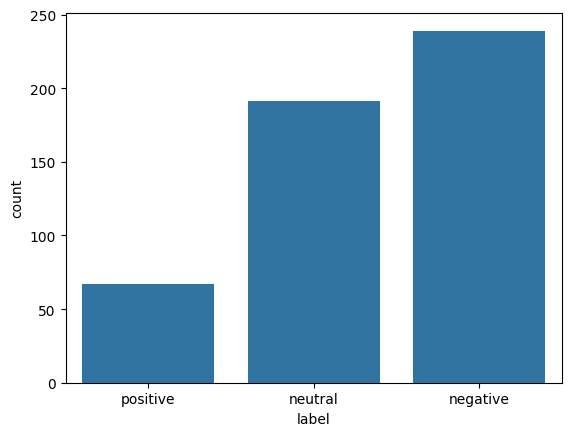

In [ ]:
# Visualise the sentiment distribution
sns.countplot(x ='label', data = df)

# Kesimpulan Hasil

bedasarkan result yang telah dilakukan ditemukan perbandingan

In [44]:
lexical= pd.read_csv("/content/hasil_sentimen.csv")
lexical

,translate_text,sentiment
0,minutes of yapping prabowo great nation day ag...,Positif
1,summarize the president's speech on the birthd...,Netral
2,just in cabinet secretary teddy responds to cr...,Netral
3,I only know how to insert Kompas TV but the sm...,Positif
4,"That's it, guys, one word at a time, Prabs tex...",Positif
...,...,...
492,"Ah, stupid, don't be strong, foreigners bother...",Negatif
493,"hahaha, they even robbed state resources, stat...",Positif
494,"I don't read and write, I always vote against ...",Netral
495,"Back in the days of Megawati and Jokowi, I oft...",Positif


In [46]:
lexical['sentiment'].value_counts()

,count
sentiment,
Positif,253
Netral,149
Negatif,95


In [45]:
bert = pd.read_csv("/content/hasil_sentimen_indoBERT.csv")
bert

,full_text,label
0,notulen yapping prabowo hari ini kita bangsa b...,positive
1,rangkuman pidato presiden di hari lahir pancas...,neutral
2,just in Sekretaris Kabinet teddy merespon krit...,neutral
3,saya tahu ini cuma insert dari kompas tv but i...,positive
4,udah beres guys ini satu satunya kata yang diu...,negative
...,...,...
492,ah bodo amat tidak usah kekuatan asing repot-r...,negative
493,hhahaha bahkan mereka-mereka merampok kedaulat...,negative
494,gak baca tulisan saya selalu pilih lawannya pr...,negative
495,kebalikannya ketika jaman megawati hingga joko...,negative


In [47]:
bert['label'].value_counts()

,count
label,
negative,239
neutral,191
positive,67


bedasarkan result terlihat mempunyai perbedaan besar pada jumlah sentimen pada kedua model.jumlah positif pada model indoBERT turun jauh ke 67 sedangkan pada Lexical Semantics 'TextBlob' 253 sentimen.

Kemudian dibagian sentimen Negatif versi indoBERT punya jumlah yang cukup besar 239 sedangkan pada Lexical Semantics 'TextBlob' 149. Ada selisih 90 sentimen pada kedua model hal ini disebabkan oleh banyaknya sentimen yang mengandung sarkasme dan ironi. sentimen yang punya makna positif secara lexical semantics pada Computational Semantics akan di patahkan saat suatu kalimat mengandung makna sarkasm

## *Contoh Perbandingan*

sentimen Versi BERT

> jujur dengar pidato presiden apalagi sudah mulai baca teks isinya
kacang rebus katanya kelompok padahal lingkaran dia juga korupsi penyeludupan ekonomi ilegal dll

Hasil : Negatif


Sentimen Versi TextBlob


> To be honest, listening to the president's speech, starting to read
the text containing boiled peanuts, said the group, even though the ring of corruption, illegal economic smuggling

Hasil : Positif





sentimen Versi BERT

> kalau kita simak pidato hari ini sih intinya sama aja cuma pakai bahasa yang udah dipoles tetep ngablu dan abstrak.


Hasil : Negatif


Sentimen Versi TextBlob


> If you listen to today's speech, the gist of it is the same, just using polished language but still not being abstract

Hasil : Netral


sentimen Versi BERT

> kalau dipikir pikir setiap prabowo pidato jadi mirip gufron alias asbun


Hasil : Negatif


Sentimen Versi TextBlob


> If you think about it, Prabowo's speech looks like Gufron, aka Asbun

Hasil : Netral



sentimen Versi BERT

> tonton pidato spektakuler dari pemimpin kolombia bikin pidato prabowo jadi sampah pidato prabowo menjilat pantat israel sementara pidato pemimpin kolombia isinya serangan penuh kpd israel as trump netanyahu negara2 eropa yang dukung israel prabowo harusnya malu


Hasil : Negatif


Sentimen Versi TextBlob


> Watch the spectacular speech of the Colombian leader, making Prabowo's speech rubbish. Prabowo's speech licks Israel's ass. The Colombian leader's speech contains a full attack on Israel, US Trump Netanyahu. European countries supporting Israel. Prabowo should be ashamed

Hasil : Netral

